# Transición a la Clasificación y la Función Sigmoide

## El límite matemático de la Regresión Lineal en espacios binarios

Hasta este punto de la sesión, hemos modelado variables continuas ($\hat{y} \in \mathbb{R}$), como el costo en dólares de un seguro médico. Sin embargo, una gran proporción de los problemas industriales requiere modelar variables objetivo discretas y binarias ($y \in \{0, 1\}$), como predecir si un paciente desarrollará una enfermedad, si una transacción es fraudulenta, o si un cliente abandonará un servicio (Churn).

Si intentamos aplicar una Regresión Lineal estándar ($\hat{y} = X\beta$) a un vector objetivo de ceros y unos, nos enfrentamos a una inconsistencia matemática fundamental. La línea recta se extenderá infinitamente en ambas direcciones, produciendo inevitablemente predicciones donde $\hat{y} < 0$ o $\hat{y} > 1$. Dado que en clasificación buscamos estimar la probabilidad de que una observación pertenezca a la clase positiva, una probabilidad negativa o superior al 100% carece de sentido axiomático.

## La Función Sigmoide como enlace probabilístico

Para resolver esta inconsistencia sin descartar la combinación lineal de características ($z = X\beta$) que nuestro modelo ya sabe calcular, introducimos una transformación no lineal que comprime cualquier valor real en el rango estricto $(0, 1)$. La función estándar para esta tarea es la Función Logística o Sigmoide:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$
* ***Propiedades asintóticas***:
    * Cuando $z \to \infty$, $e^{-z} \to 0$, por lo tanto $\sigma(z) \to 1$.
    * Cuando $z \to -\infty$, $e^{-z} \to \infty$, por lo tanto $\sigma(z) \to 0$.
    * Cuando $z = 0$, $\sigma(z) = 0.5$ (El umbral de decisión natural).

La salida de esta función, $\hat{p} = \sigma(X\beta)$, se interpreta rigurosamente como la probabilidad condicional de que la clase sea 1, dado el vector de características $X$.

El objetivo es entrenar o encontrar un conjunto de parámetros $ \{ \beta _i \}$ de forma que el modelo estime las probabilidades altas para instancias positivas ($y = 1$) y probablidades bajas para instancias negativas ($y = 0$). Esta idea debe capturarse en la función de costo para una instancia de entrenamiento ${X}$.

In [64]:
# Importar las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns                                                   # NUEVO para mejorar la visualización
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression                     # NUEVO para regresión logística
from sklearn.preprocessing import PolynomialFeatures, StandardScaler    # Para características polinómicas y escalado
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [65]:
# Implementación matemática de la Función Sigmoide
def funcion_sigmoide(z):
    return 1 / (1 + np.exp(-z))

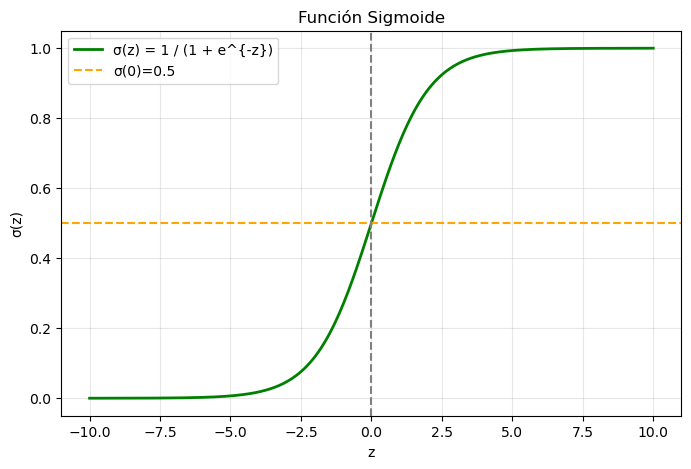

In [66]:
# Graficar la función sigmoide para entender su forma
z = np.linspace(-10, 10, 400)
sig = funcion_sigmoide(z)

plt.figure(figsize=(8, 5))
plt.plot(z, sig, color='green', linewidth=2, label='σ(z) = 1 / (1 + e^{-z})')
plt.axhline(0.5, color='orange', linestyle='--', label='σ(0)=0.5')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Función Sigmoide')
plt.xlabel('z')
plt.ylabel('σ(z)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [67]:
# Simulación de un problema de clasificación binaria (ej. Biomarcador vs Presencia de Enfermedad)
np.random.seed(42)
n_samples = 60

# Generamos dos distribuciones separadas para la clase 0 y la clase 1
X_biomarcador = np.concatenate([np.random.normal(30, 8, n_samples//2), 
                                np.random.normal(60, 8, n_samples//2)])
y_binario = np.concatenate([np.zeros(n_samples//2), np.ones(n_samples//2)])

X_reshaped = X_biomarcador.reshape(-1, 1)

# 2. Ajuste de Regresión Lineal Clásica (El enfoque incorrecto)
lr_invalido = LinearRegression()
lr_invalido.fit(X_reshaped, y_binario)

# Espacio de inferencia para trazar las curvas
x_rango = np.linspace(0, 90, 300).reshape(-1, 1)
y_pred_lineal = lr_invalido.predict(x_rango)

# Simulamos los pesos ajustados de una regresión logística para la demostración
# (z = beta_1 * x + beta_0)
z_valores = (x_rango - 45) * 0.15 
y_pred_sigmoide = funcion_sigmoide(z_valores)

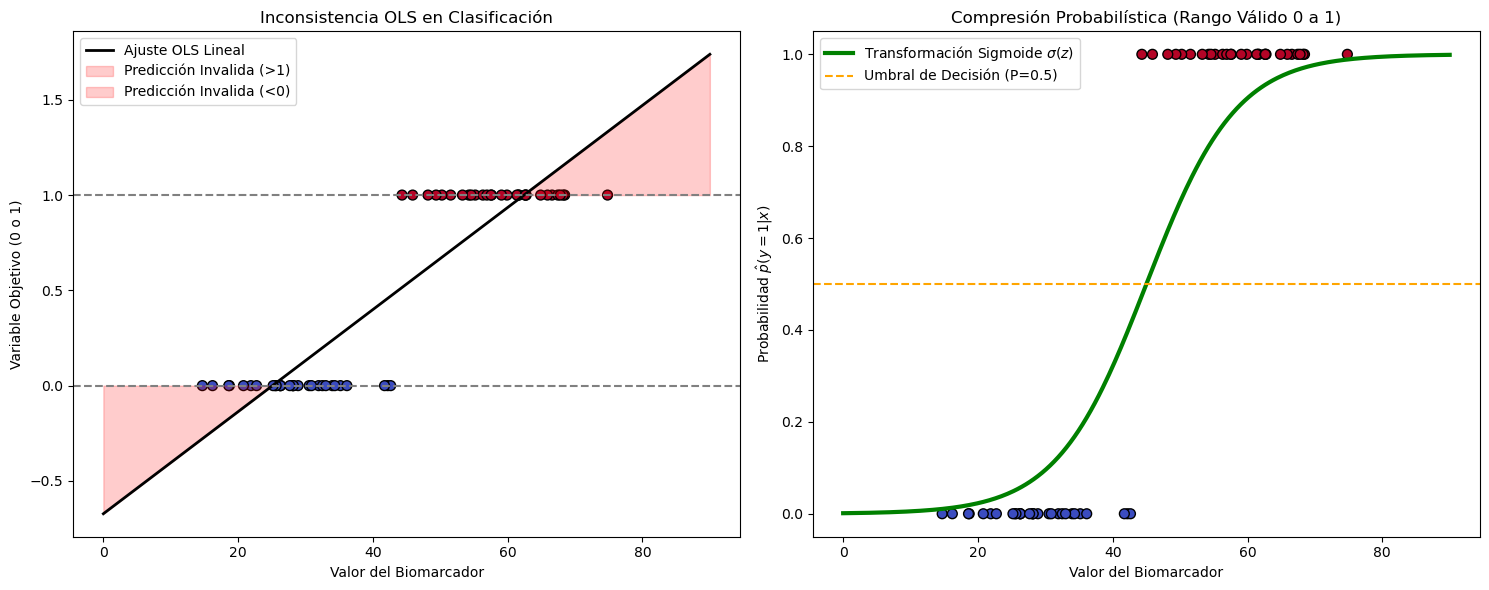

In [68]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: El fallo de la Regresión Lineal
axes[0].scatter(X_biomarcador, y_binario, c=y_binario, cmap='coolwarm', edgecolors='k', s=50)
axes[0].plot(x_rango, y_pred_lineal, 'k-', linewidth=2, label='Ajuste OLS Lineal')
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].axhline(1, color='gray', linestyle='--')
axes[0].fill_between(x_rango.flatten(), y_pred_lineal, 1, where=(y_pred_lineal > 1), color='red', alpha=0.2, label='Predicción Invalida (>1)')
axes[0].fill_between(x_rango.flatten(), y_pred_lineal, 0, where=(y_pred_lineal < 0), color='red', alpha=0.2, label='Predicción Invalida (<0)')
axes[0].set_title('Inconsistencia OLS en Clasificación')
axes[0].set_xlabel('Valor del Biomarcador')
axes[0].set_ylabel('Variable Objetivo (0 o 1)')
axes[0].legend()

# Gráfico 2: La corrección de la Función Sigmoide
axes[1].scatter(X_biomarcador, y_binario, c=y_binario, cmap='coolwarm', edgecolors='k', s=50)
axes[1].plot(x_rango, y_pred_sigmoide, 'g-', linewidth=3, label='Transformación Sigmoide $\sigma(z)$')
axes[1].axhline(0.5, color='orange', linestyle='--', label='Umbral de Decisión (P=0.5)')
axes[1].set_title('Compresión Probabilística (Rango Válido 0 a 1)')
axes[1].set_xlabel('Valor del Biomarcador')
axes[1].set_ylabel('Probabilidad $\hat{p}(y=1|x)$')
axes[1].legend()

plt.tight_layout()
plt.show()

# ¿Por qué MSE falla aquí? El concepto de Log-Loss

En regresión lineal, usamos el MSE (Error Cuadrático Medio). El MSE penaliza la distancia. Si predigo que una casa vale 100 y vale 120, mi error es 20. Si predigo 140, mi error sigue siendo 20. Es simétrico y proporcional.
Pero en clasificación, no medimos distancias, medimos la confianza. Imagina que un paciente tiene cáncer ($y=1$).
* ***Modelo A***: Predice una probabilidad de 0.1 (10% seguro de que tiene cáncer). Se equivocó.
* ***Modelo B***: Predice una probabilidad de 0.0001 (0.01% seguro). Estaba arrogantemente seguro de que el paciente estaba sano, y se equivocó.

El MSE castigaría a ambos modelos de forma muy similar (la diferencia al cuadrado entre 1 y casi 0 es cercana a 1 en ambos casos). ¡Pero el Modelo B es mucho más peligroso! Un modelo que está extremadamente seguro de una predicción incorrecta necesita un castigo más severo.

La nueva métrica, basada en la verosimilitud logaritmica. Esta es una función que, al contrario del MSE, queremos maximizar (queremos que las probabilidades de acertar sean lo más altas posibles).

$$\mathcal{L}(\beta) = \sum_{i} \left[ y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i) \right]$$

En Machine Learning, por convención, nos gusta minimizar errores. Así que multiplicamos esto por -1 y lo promediamos, obteniendo nuestra famosa función de costo para clasificación: Binary Cross-Entropy o Log-Loss.


$$\mathcal{J}(\beta) = - \sum_{i} \left[ y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i) \right]$$

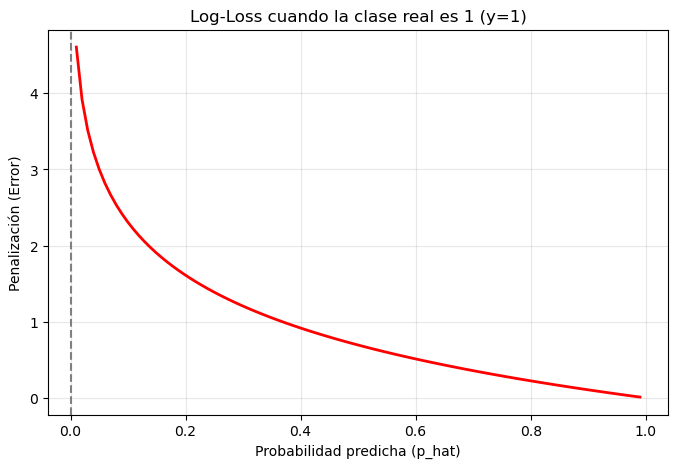

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# Simulamos predicciones de probabilidad de 0.01 a 0.99
p_hat = np.linspace(0.01, 0.99, 100)

# Calculamos el error Log-Loss asumiendo que la respuesta real era 1 (y=1)
# Si y=1, la fórmula se simplifica a: -log(p_hat)
log_loss_y1 = -np.log(p_hat)

plt.figure(figsize=(8, 5))
plt.plot(p_hat, log_loss_y1, color='red', linewidth=2)
plt.title('Log-Loss cuando la clase real es 1 (y=1)')
plt.xlabel('Probabilidad predicha (p_hat)')
plt.ylabel('Penalización (Error)')
plt.axvline(x=0, color='gray', linestyle='--')
plt.grid(True, alpha=0.3)
plt.show()

# Gradiente descendente sobre Log-Loss

Ahora que tenemos una nueva función de error, necesitamos minimizarla. En regresión lineal usamos el Gradiente Descendente. ¿Tendremos que aprender un algoritmo completamente nuevo?

La respuesta es, NO. 

Si tomamos esa función Log-Loss (que parece intimidante) y calculamos su derivada (su gradiente) respecto a nuestros pesos $\beta$, después de hacer un poco de álgebra, llegamos a esto:

$$\frac{\partial J}{\partial \beta_j} = \frac{1}{n} \sum_i (\hat{p}_i - y_i) x_{ij}$$

Es exactamente la misma forma que el gradiente de la Regresión Lineal Múltiple que vimos. La única diferencia estructural es cómo calculamos la predicción:

* ***En regresión lineal***: $\hat{y}_i = X\beta$
* ***En regresión logística***: $\hat{p}_i = \sigma(X\beta)$ (pasamos el resultado por la sigmoide).

Esto significa que la regla de actualización del Gradiente Descendente funciona sin modificaciones. Veamos cómo se ve esto en código

In [70]:
def gradient_descent_logistic(X, y, learning_rate=0.01, epochs=1000):
    m, n = X.shape
    beta = np.zeros(n) # Inicializamos pesos en 0
    
    for epoch in range(epochs):
        # 1. Calculamos la combinación lineal (z)
        z = np.dot(X, beta)
        
        # 2. Pasamos z por la funcion sigmoide para obtener probabilidades
        p_hat = funcion_sigmoide(z)
        
        # 3. Calculamos el gradiente (¡Misma fórmula que regresión lineal!)
        gradient = np.dot(X.T, (p_hat - y)) / m
        
        # 4. Actualizamos los pesos
        beta -= learning_rate * gradient
        
    return beta

#Un clasificador logístico funcional desde cero.

## Frontera de decisión

Hasta ahora nuestro modelo calcula probabilidades (por ejemplo, 0.82). Pero el usuario final no quiere una probabilidad, quiere una decisión: ¿Es spam o no es spam? ¿Apruebo el crédito o lo rechazo?

Para convertir probabilidades en clases discretas, usamos un umbral (threshold). El más intuitivo es 0.5:

* Si $\hat{p} \geq 0.5 \implies$ Clase 1

* Si $\hat{p} < 0.5 \implies$ Clase 0

Matemáticamente, si $\hat{p} = 0.5$, significa que $\sigma(X\beta) = 0.5$, lo cual solo ocurre cuando el exponente es cero, es decir, cuando $X\beta = 0$.

En un gráfico de 2 dimensiones (dos variables), $X\beta = 0$ dibuja una línea recta. En múltiples dimensiones, es un hiperplano. Esa es nuestra Frontera de Decisión.

El modelo te da probabilidades. Poner el umbral en 0.5 es una convención técnica, pero mover el umbral es una decisión de negocio. Si estás prediciendo si un avión tiene una falla en el motor, no esperas a estar 50% seguro para revisarlo. Quizás con un 0.1 (10% de probabilidad) ya envías al mecánico.

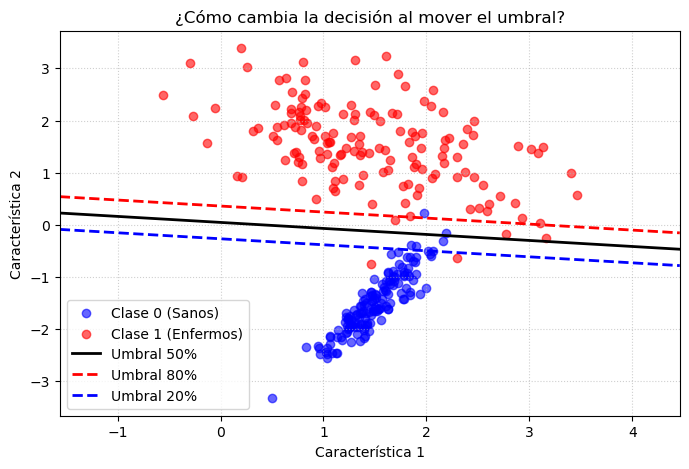

In [71]:
from sklearn.datasets import make_classification

# --- GENERACIÓN DE DATOS Y ENTRENAMIENTO ---
# Generamos 300 puntos sintéticos con 2 características
X, y = make_classification(n_samples=300, n_features=2, n_redundant=0, 
                           n_clusters_per_class=1, random_state=42, class_sep=1.5)

# ¡Importante! Añadimos una columna de 1s a X para el término del "sesgo" (intercepto)
X_bias = np.c_[np.ones((X.shape[0], 1)), X]

# Entrenamos el modelo usando tu función (aumentamos learning rate y epochs)
beta_optimo = gradient_descent_logistic(X_bias, y, learning_rate=0.1, epochs=2000)

# ---VISUALIZACIÓN DE FRONTERAS Y UMBRALES ---

plt.figure(figsize=(8, 5))

# Dibujamos los puntos reales
plt.scatter(X[y==0, 0], X[y==0, 1], color='blue', label='Clase 0 (Sanos)', alpha=0.6)
plt.scatter(X[y==1, 0], X[y==1, 1], color='red', label='Clase 1 (Enfermos)', alpha=0.6)

# Tomamos los valores mínimo y máximo del eje X para trazar nuestras líneas
x1_valores = np.array([X[:, 0].min() - 1, X[:, 0].max() + 1])

# Función para dibujar la línea exacta según el umbral que queramos
def calcular_linea_umbral(probabilidad_deseada):
    # Usamos la inversa de la sigmoide para saber el valor de 'z'
    z = np.log(probabilidad_deseada / (1 - probabilidad_deseada))
    
    # Despejamos el eje Y (x2) de la ecuación: beta0 + beta1*x1 + beta2*x2 = z
    x2_valores = (z - beta_optimo[0] - beta_optimo[1] * x1_valores) / beta_optimo[2]
    return x2_valores

# Dibujamos las 3 líneas rectas usando la función auxiliar
plt.plot(x1_valores, calcular_linea_umbral(0.5), 'k-', linewidth=2, label='Umbral 50%')
plt.plot(x1_valores, calcular_linea_umbral(0.8), 'r--', linewidth=2, label='Umbral 80%')
plt.plot(x1_valores, calcular_linea_umbral(0.2), 'b--', linewidth=2, label='Umbral 20%')

# Detalles finales del gráfico
plt.title('¿Cómo cambia la decisión al mover el umbral?')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.xlim(x1_valores) # Ajustamos los bordes del gráfico
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

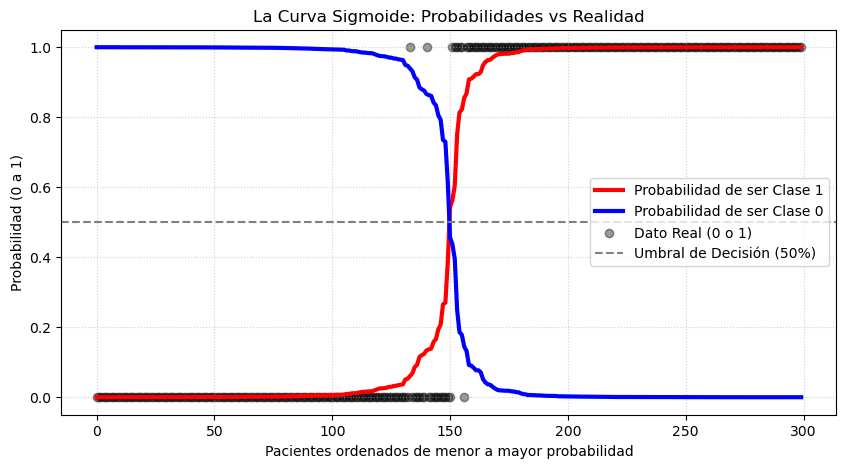

In [72]:
# --- CALCULAMOS LAS PROBABILIDADES ---
# Multiplicamos los datos por los pesos que aprendió el modelo
z = np.dot(X_bias, beta_optimo)

# Pasamos 'z' por la función sigmoide para obtener porcentajes (0 a 1)
probabilidades_clase_1 = funcion_sigmoide(z)

# --- ORDENAR LOS DATOS ---
# np.argsort nos dice en qué orden poner a los pacientes para ir del más seguro(0) al más seguro(1)
orden_pacientes = np.argsort(probabilidades_clase_1)

# Aplicamos ese orden a nuestras probabilidades y a las respuestas reales
probs_1_ordenadas = probabilidades_clase_1[orden_pacientes]
probs_0_ordenadas = 1 - probs_1_ordenadas # Lo que falta para el 100%
etiquetas_reales_ordenadas = y[orden_pacientes]

# --- VISUALIZACIÓN ---
plt.figure(figsize=(10, 5))

# Dibujamos las famosas curvas 'sigmoides' para ambas clases
plt.plot(probs_1_ordenadas, color='red', linewidth=3, label='Probabilidad de ser Clase 1')
plt.plot(probs_0_ordenadas, color='blue', linewidth=3, label='Probabilidad de ser Clase 0')

# Dibujamos los datos reales 
plt.scatter(range(len(etiquetas_reales_ordenadas)), etiquetas_reales_ordenadas, 
            color='black', alpha=0.4, label='Dato Real (0 o 1)')

# Línea del umbral
plt.axhline(y=0.5, color='gray', linestyle='--', label='Umbral de Decisión (50%)')

plt.title('La Curva Sigmoide: Probabilidades vs Realidad')
plt.xlabel('Pacientes ordenados de menor a mayor probabilidad')
plt.ylabel('Probabilidad (0 a 1)')
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

# El puente hacia la industria

Todo lo anterior es únicamente el ejercio acádemico. En la industria lo común es emplear código optimzado y escalable para ello empleamos `scikit-learn`. 

## El Pipeline

A diferencia de la Regresión Lineal ordinaria, la implementación de Regresión Logística en scikit-learn incluye regularización por defecto (una técnica para evitar el sobreajuste que penaliza los coeficientes muy grandes). Si las variables de entrada tienen escalas diferentes (por ejemplo, la edad va de 18 a 90, pero el salario va de 1000 a 100000), la regularización castigará injustamente a las variables con valores numéricos pequeños. Para evitar esto, usamos StandardScaler dentro de un Pipeline para garantizar que todo el proceso sea replicable y sin fugas de datos.

* `solver='lbfgs'`: En regresión lineal existía una fórmula exacta para encontrar los pesos. En regresión logística no hay una ecuación cerrada. El modelo debe iterar para encontrar el mínimo del Log-Loss. lbfgs es el algoritmo de optimización que hace esto. Es una versión mucho más sofisticada y rápida del Gradiente Descendente que acabamos de ver.

* `max_iter=1000`: A veces, el solver necesita más intentos (iteraciones) para encontrar el mínimo. El valor por defecto es 100, pero suele quedarse corto y arrojar advertencias. Subirlo a 1000 es una buena práctica inicial.

* `random_state=42`: Garantiza que, si ejecutamos el código múltiples veces, la inicialización de los pesos comience en el mismo punto, haciendo que los resultados sean reproducibles.


In [73]:
from sklearn.datasets import make_classification       # NUEVO para generar datos sintéticos de clasificación

# Creamos un conjunto de datos ficticio (ej. 500 pacientes, 4 signos vitales)
# La suma informative+redundant+repeated debe ser < n_features
X, y = make_classification(
    n_samples=500,
    n_features=4,
    n_informative=3,
    n_redundant=0,
    random_state=42,
    class_sep=1.5
)

# Dividimos los datos: 80% para entrenar (X_train) y 20% para probar (X_test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 1. Definimos la arquitectura de nuestro modelo
pipeline_logistico = Pipeline([
    ('escalador', StandardScaler()), 
    ('clasificador', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42))
])

# 2. Entrenamos el modelo (ajustamos el escalador y encontramos los pesos beta)
# Asumimos que X_train y y_train ya están definidos en el entorno
pipeline_logistico.fit(X_train, y_train)

# 3. La predicción cruda (Clases 0 o 1)
# El modelo usa internamente el umbral estricto de 0.5
predicciones_clase = pipeline_logistico.predict(X_test)
print("Predicciones de clase (0 o 1):", predicciones_clase[:5])

# 4. Extrayendo las probabilidades reales
probabilidades = pipeline_logistico.predict_proba(X_test)

# predict_proba devuelve una matriz con DOS columnas.
# Columna 0: Probabilidad de pertenecer a la clase 0
# Columna 1: Probabilidad de pertenecer a la clase 1
print("\nMatriz de probabilidades (Clase 0, Clase 1):")
print(probabilidades[:5])

# Por lo general, solo nos interesa la probabilidad de la clase positiva (Clase 1)
probabilidades_clase_1 = probabilidades[:, 1]
print("\nProbabilidad exacta de ser Clase 1:")
print(probabilidades_clase_1[:5])

Predicciones de clase (0 o 1): [0 0 1 0 1]

Matriz de probabilidades (Clase 0, Clase 1):
[[0.64675597 0.35324403]
 [0.97411625 0.02588375]
 [0.19368178 0.80631822]
 [0.96662806 0.03337194]
 [0.00744161 0.99255839]]

Probabilidad exacta de ser Clase 1:
[0.35324403 0.02588375 0.80631822 0.03337194 0.99255839]


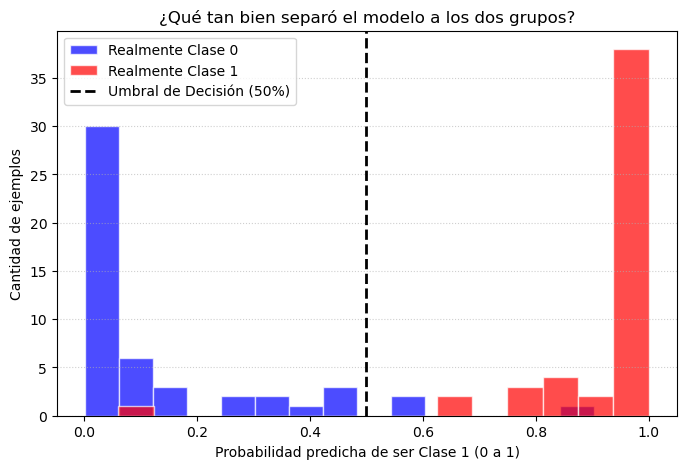

In [74]:
plt.figure(figsize=(8, 5))

# Filtramos las probabilidades según la respuesta correcta (la clase real)
probs_reales_0 = probabilidades_clase_1[y_test == 0] # Los que realmente son 0
probs_reales_1 = probabilidades_clase_1[y_test == 1] # Los que realmente son 1

# Dibujamos los histogramas (cuántos pacientes caen en cada nivel de probabilidad)
plt.hist(probs_reales_0, bins=15, alpha=0.7, color='blue', label='Realmente Clase 0', edgecolor='white')
plt.hist(probs_reales_1, bins=15, alpha=0.7, color='red', label='Realmente Clase 1', edgecolor='white')

# Dibujamos una línea recta donde está nuestro umbral de decisión actual (0.5)
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Umbral de Decisión (50%)')

# Detalles decorativos para que se entienda fácil
plt.title('¿Qué tan bien separó el modelo a los dos grupos?')
plt.xlabel('Probabilidad predicha de ser Clase 1 (0 a 1)')
plt.ylabel('Cantidad de ejemplos')
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.show()

* La zona segura azul (Izquierda): Significa que el modelo vio a esos pacientes (que realmente son Clase 0) y nos indica: "Estoy casi 100% seguro de que estos son Clase 0". 

* La zona segura roja (Derecha): Aquí verán barras rojas cerca del 1.0. El modelo indica: "Estoy muy seguro de que estos son Clase 1". ¡También es bueno!

* La zona de confusión (El centro): Cerca de la línea punteada del umbral (0.5). Si hay barras azules a la derecha del umbral, son Falsos Positivos. Si hay barras rojas a la izquierda del umbral, son Falsos Negativos.

# Metricas de evaluación

Para poner a prueba nuestro clasificador, vamos a trabajar con un problema del mundo real. Retomando el contexto de salud que manejamos con el conjunto de datos de seguros médicos, ahora abordaremos un reto de clasificación binaria: predecir si un paciente tiene diabetes o no basándonos en métricas clínicas.

Este conjunto de datos es ideal para nuestra clase por una razón principal: presenta un desbalance de clases. Aproximadamente el 35% de los pacientes en esta muestra tienen diabetes (clase positiva) y el 65% no la tienen (clase negativa). Este desbalance nos obligará a ir más allá de las métricas de evaluación tradicionales.

In [75]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
        'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']
df = pd.read_csv(url, names=cols)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## La Matriz de Confusión 

Una vez que el modelo hace predicciones, necesitamos evaluarlo. En regresión lineal mirábamos los residuos. En clasificación binaria miramos los cuatro posibles escenarios de acierto y error. Vamos a aterrizar estos cuatro cuadrantes al contexto de nuestros datos:

* ***Verdadero Positivo (TP)***: El modelo predijo diabetes y el paciente realmente tiene diabetes. Un acierto crucial para iniciar el tratamiento.

* ***Verdadero Negativo (TN)***: El modelo predijo sano y el paciente está sano. Un acierto que ahorra recursos.

* ***Falso Positivo (FP - Error Tipo I)***: El modelo predice diabetes, pero el paciente está sano. Es una falsa alarma. Genera estrés en el paciente y un gasto innecesario en exámenes adicionales (costo económico).

* ***Falso Negativo (FN - Error Tipo II)***: El modelo predice sano, pero el paciente tiene diabetes. Es un diagnóstico omitido. El paciente se va a casa sin tratamiento y su salud empeorará (costo altísimo).

En este escenario médico, ¿qué error es más peligroso para el sistema de salud? 

### Precision, Recall y F1-Score 

Si solo usamos la "Exactitud" (Accuracy), calculando el porcentaje total de aciertos, el modelo nos puede engañar. Si un modelo inútil simplemente dice "Ningún paciente tiene diabetes", acertará el 65% de las veces debido al desbalance natural de los datos. Un 65% suena a que el modelo hace algo, pero en realidad no detectó ni un solo caso real.

Para resolver esto, utilizamos tres métricas fundamentales derivadas de la matriz de confusión:
|Métrica|Pregunta que responde|Cuándo priorizar|
| :--- | :--- | :--- |
| **Precision** | De los que el modelo marcó como positivos, ¿cuántos lo eran realmente? | Cuando el FP es costoso (ejemplo: marcar un correo importante como Spam).|
| **Recall (Sensibilidad)** | De todos los positivos reales que existen, ¿cuántos logró detectar el modelo? | Cuando el FN es costoso (ejemplo: detectar enfermedades graves o fraudes bancarios).| 
| **F1-Score** | ¿Cuál es el balance entre los dos anteriores? | Cuando las clases están desbalanceadas y no tienes un contexto de negocio claro para priorizar.|


El F1-Score no es un promedio simple, es una media armónica. Penaliza fuertemente a los modelos que tienen una métrica muy alta y la otra muy baja:$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

In [76]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [77]:
#  División en características (X) y objetivo (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Construcción y entrenamiento del Pipeline
pipeline_diabetes = Pipeline([
    ('poly', PolynomialFeatures(degree=1)), # degree=1 es equivalente a dejar las variables originales
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42))
])

pipeline_diabetes.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",1
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


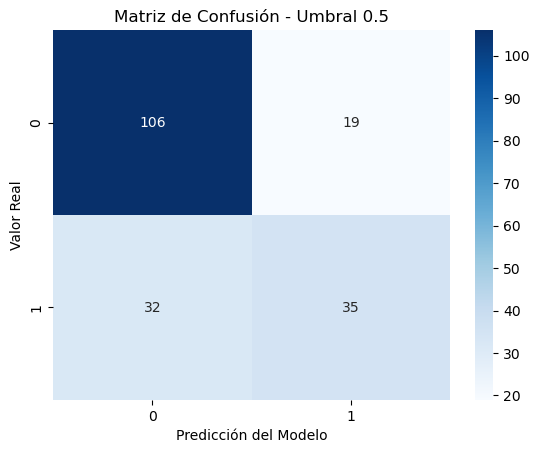

              precision    recall  f1-score   support

           0       0.77      0.85      0.81       125
           1       0.65      0.52      0.58        67

    accuracy                           0.73       192
   macro avg       0.71      0.69      0.69       192
weighted avg       0.73      0.73      0.73       192



In [78]:
from sklearn.metrics import classification_report, confusion_matrix     # NUEVO para evaluar el modelo con métricas de clasificación

# Generamos predicciones con el umbral por defecto (0.5)
y_pred = pipeline_diabetes.predict(X_test)

# 1. Visualizamos la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.title('Matriz de Confusión - Umbral 0.5')
plt.show()

# 2. Imprimimos el reporte de métricas
print(classification_report(y_test, y_pred))

###  Variando el umbral de decisión manualmente
La función `.predict()` toma la probabilidad que escupe la regresión logística y aplica un corte estricto en 0.5. Como discutimos, al priorizar evitar los Falsos Negativos en nuestro contexto médico, exigirle al modelo que esté un 50% seguro puede ser demasiado estricto.

¿Qué pasa si decidimos que con solo un 30% de probabilidad (0.3) ya queremos enviar al paciente a revisión médica?

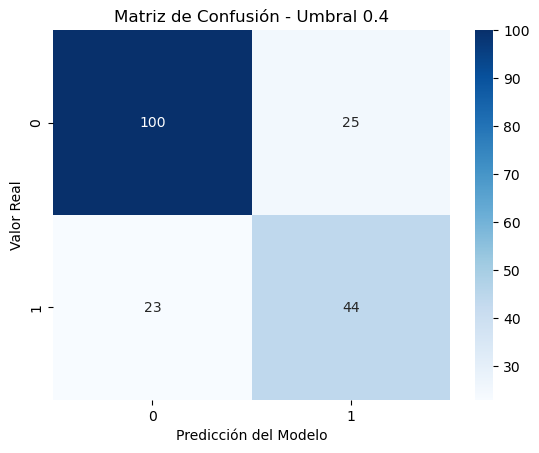

--- Métricas con Umbral 0.4 ---
              precision    recall  f1-score   support

           0       0.81      0.80      0.81       125
           1       0.64      0.66      0.65        67

    accuracy                           0.75       192
   macro avg       0.73      0.73      0.73       192
weighted avg       0.75      0.75      0.75       192



In [79]:
# Obtenemos las probabilidades puras (columna 1 para la clase positiva)
probabilidades = pipeline_diabetes.predict_proba(X_test)[:, 1]

# Definimos nuestro propio umbral de negocio
umbral_personalizado = 0.4

#  Creamos nuevas predicciones basadas en este umbral
y_pred_personalizado = np.where(probabilidades >= umbral_personalizado, 1, 0)

# Evaluamos el impacto
# Visualizamos la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_personalizado)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.title(f'Matriz de Confusión - Umbral {umbral_personalizado}')
plt.show()


print(f"--- Métricas con Umbral {umbral_personalizado} ---")
print(classification_report(y_test, y_pred_personalizado))

# Curva ROC y regularización

En el bloque anterior descubrimos un problema operativo: cambiar el umbral a mano (0.5, luego 0.3, luego 0.7) para ver cómo cambian las métricas es como intentar afinar una guitarra girando las clavijas a ciegas. Necesitamos un "mapa" que nos muestre todos los umbrales posibles y sus consecuencias al mismo tiempo. Ese mapa es la Curva ROC (Receiver Operating Characteristic).

## ¿Qué es la curva ROC?

Para entender la curva, primero debemos entender sus ejes, que provienen directamente de la matriz de confusión que acabamos de aprender:

* ***Eje Y***: TPR (True Positive Rate o Sensibilidad). Su fórmula es $$TPR = \frac{TP}{TP + FN}$$ De todos los pacientes que realmente tienen diabetes, ¿qué porcentaje logramos atrapar? Queremos que este número sea lo más cercano a 1 (o 100%) posible. Es exactamente lo mismo que el Recall.

* ***Eje X***: FPR (False Positive Rate o Tasa de Falsas Alarmas). Su fórmula es $$FPR = \frac{FP}{FP + TN}$$ De todos los pacientes que están completamente sanos, ¿a qué porcentaje asustamos equivocadamente diciéndoles que tenían la enfermedad? Queremos que este número sea lo más cercano a 0 posible.

La curva ROC no evalúa el modelo en un solo punto de decisión de 0.5. Es el registro histórico de lo que le pasa a nuestro modelo cuando barremos el umbral de decisión desde el extremo más estricto hasta el más relajado.

## Supervivencia en el Titanic 

Vamos a cambiar radicalmente de dominio para demostrar que el mismo flujo de trabajo funciona en contextos completamente distintos. Evaluaremos el famoso dataset del Titanic, donde el objetivo es predecir si un pasajero sobrevivió ($y=1$) o no ($y=0$).

In [80]:
# Carga de datos
titanic = sns.load_dataset('titanic')

# Seleccionamos variables clave para el ejemplo
features = ['pclass', 'sex', 'age', 'fare']
X = titanic[features]
y = titanic['survived']

X.head()

,pclass,sex,age,fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500


In [81]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

In [82]:
X.describe()

,pclass,age,fare
count,891.000000,714.000000,891.000000
mean,2.308642,29.699118,32.204208
std,0.836071,14.526497,49.693429
min,1.000000,0.420000,0.000000
25%,2.000000,20.125000,7.910400
50%,3.000000,28.000000,14.454200
75%,3.000000,38.000000,31.000000
max,3.000000,80.000000,512.329200


In [83]:
# Revisar datos faltantes en el dataset actual (Titanic)
faltantes_por_columna = X.isnull().sum()
porcentaje_faltantes = (faltantes_por_columna / len(X) * 100).round(2)

resumen_faltantes = pd.DataFrame({
    'faltantes': faltantes_por_columna,
    'porcentaje_%': porcentaje_faltantes
}).sort_values(by='faltantes', ascending=False)

print("Resumen de datos faltantes en X:")
print(resumen_faltantes)

print("\n¿Hay datos faltantes en y?:", y.isnull().any())
print("Cantidad de faltantes en y:", y.isnull().sum())

Resumen de datos faltantes en X:
        faltantes  porcentaje_%
age           177         19.87
pclass          0          0.00
sex             0          0.00
fare            0          0.00

¿Hay datos faltantes en y?: False
Cantidad de faltantes en y: 0


Si intentamos meter esta matriz $X$ directamente a la fórmula de la Regresión Logística ($z = X\beta$), podemos tener problemas. No se puede multiplicar un peso $\beta$ por un valor "vacío" o "nulo" (NaN o Null).

***¿Qué opciones tenemos?***

1. ***Borrar a esos 177 pasajeros***: Perderíamos el 20% de nuestra información. Es demasiado costoso.

2. ***Inventarnos el dato (Imputación)***: Podemos rellenar esos huecos con un valor razonable, por ejemplo, la edad promedio de todos los demás pasajeros en el barco.

In [84]:
from sklearn.impute import SimpleImputer                                # NUEVO para manejar datos faltantes
from sklearn.preprocessing import OneHotEncoder                         # NUEVO para escalar características numéricas y convertir categorías a números
from sklearn.compose import ColumnTransformer                           # NUEVO para aplicar diferentes transformaciones a columnas numéricas y categóricas

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Pipeline para números: Primero tapa los huecos (Imputer), luego escala (Scaler)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), 
    ('scaler', StandardScaler())
])

# Pipeline para categorías: Convierte texto a números (One-Hot Encoding)
cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Unimos ambos preprocesamientos indicando a qué columnas aplicar qué cosa
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, ['age', 'fare']),
        ('cat', cat_transformer, ['pclass', 'sex'])
    ])

# Pipeline final que termina en la Regresión Logística
pipeline_titanic = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42))
])

# Entrenamos el modelo (aquí ocurre la magia de la imputación y transformación en secreto)
pipeline_titanic.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

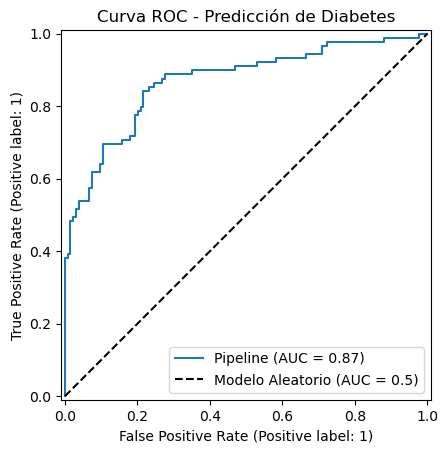

AUC del modelo: 0.8685


In [85]:
from sklearn.metrics import RocCurveDisplay                                     # NUEVO para visualizar la curva ROC
from sklearn.metrics import roc_auc_score                                       # NUEVO para calcular el AUC del modelo 

# Generamos la visualización estática usando scikit-learn
display = RocCurveDisplay.from_estimator(pipeline_titanic, X_test, y_test)
plt.title('Curva ROC - Predicción de Diabetes')
plt.plot([0, 1], [0, 1], 'k--', label='Modelo Aleatorio (AUC = 0.5)')
plt.legend()
plt.show()

auc = roc_auc_score(y_test, pipeline_titanic.predict_proba(X_test)[:, 1])
print(f"AUC del modelo: {auc:.4f}")

Para elegir el mejor umbral a partir de la curva ROC, debemos pasar de la inspección visual al cálculo matemático. Visualmente, el umbral óptimo es el punto de la curva que se encuentra más cerca de la esquina superior izquierda (coordenada 0, 1). En ese punto maximizamos los verdaderos positivos mientras mantenemos los falsos positivos al mínimo.Sin embargo, la elección final siempre depende del contexto del negocio. 

Si el costo de un falso negativo es altísimo (como no detectar una enfermedad grave o no predecir un accidente), se debe sacrificar la optimización matemática pura para empujar el umbral hacia la derecha de la curva, asegurando un Recall (TPR) mucho más cercano a 1.0, aunque aumenten los falsos positivos (FPR).

Para encontrar el punto óptimo matemáticamente cuando los falsos positivos y los falsos negativos tienen un costo similar, el método estándar en la industria es el Índice de Youden. Este estadístico maximiza la diferencia entre la tasa de verdaderos positivos y la tasa de falsos positivos: $$J = TPR - FPR$$

In [86]:
from sklearn.metrics import roc_curve                                   # NUEVO para calcular FPR, TPR y umbrales necesarios para el Índice de Youden

# 1. Obtenemos las probabilidades continuas de la clase positiva (1)
# Nota sobre tu código: el objeto se llama pipeline_titanic pero el título dice Diabetes.
# Asegúrate de usar las variables del dataset que estés explicando en ese momento.
y_pred_proba = pipeline_titanic.predict_proba(X_test)[:, 1]

# 2. Calculamos FPR, TPR y todos los umbrales evaluados para construir la curva
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 3. Calculamos el Índice de Youden para cada punto (TPR - FPR)
youden_j = tpr - fpr

# 4. Buscamos el índice donde la diferencia es máxima
best_index = np.argmax(youden_j)
best_threshold = thresholds[best_index]

print(f"El mejor umbral según el Índice de Youden es: {best_threshold:.4f}")
print(f"En este umbral específico:")
print(f"TPR (Recall): {tpr[best_index]:.4f}")
print(f"FPR (Falsas Alarmas): {fpr[best_index]:.4f}")

El mejor umbral según el Índice de Youden es: 0.3489
En este umbral específico:
TPR (Recall): 0.8427
FPR (Falsas Alarmas): 0.2164


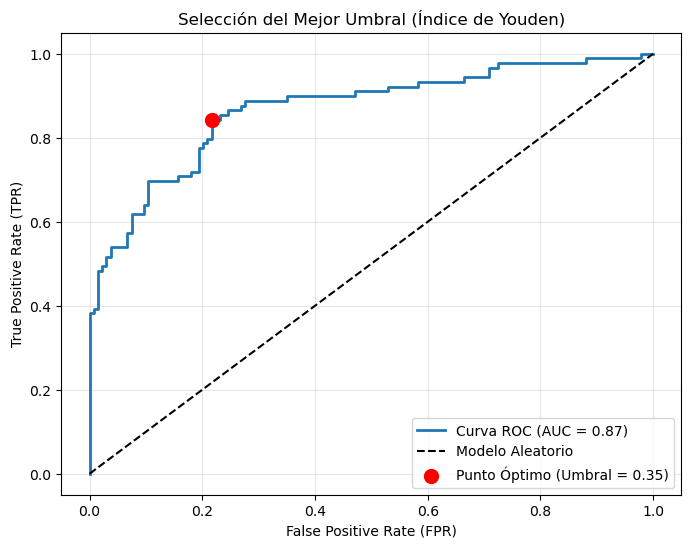

In [87]:
# 5. Visualizamos este punto óptimo en la gráfica
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Curva ROC (AUC = 0.87)', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Modelo Aleatorio')

# Resaltamos el punto óptimo
plt.scatter(fpr[best_index], tpr[best_index], color='red', marker='o', s=100, 
            label=f'Punto Óptimo (Umbral = {best_threshold:.2f})', zorder=5)

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Selección del Mejor Umbral (Índice de Youden)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [88]:
# Evaluación del modelo con umbral 0.5 y con el umbral óptimo (Youden)

# Si no existe best_threshold, lo calculamos con y_test y y_pred_proba
try:
    best_threshold
except NameError:
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    youden_j = tpr - fpr
    best_threshold = thresholds[np.argmax(youden_j)]

# Predicciones con umbral 0.5
y_pred_05 = (y_pred_proba >= 0.5).astype(int)

# Predicciones con umbral óptimo
y_pred_opt = (y_pred_proba >= best_threshold).astype(int)

print("=== Evaluación con umbral 0.5 ===")
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_05))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_05))

print(f"\n=== Evaluación con umbral óptimo (Youden = {best_threshold:.4f}) ===")
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_opt))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_opt))

=== Evaluación con umbral 0.5 ===
Matriz de confusión:
[[112  22]
 [ 26  63]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       134
           1       0.74      0.71      0.72        89

    accuracy                           0.78       223
   macro avg       0.78      0.77      0.77       223
weighted avg       0.78      0.78      0.78       223


=== Evaluación con umbral óptimo (Youden = 0.3489) ===
Matriz de confusión:
[[105  29]
 [ 14  75]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83       134
           1       0.72      0.84      0.78        89

    accuracy                           0.81       223
   macro avg       0.80      0.81      0.80       223
weighted avg       0.82      0.81      0.81       223



### Análisis del modelo con el umbral por defecto (0.5)
Al usar el límite matemático estándar del 50%, observamos el comportamiento base del clasificador. La matriz de confusión nos muestra 63 Verdaderos Positivos (sobrevivientes correctamente identificados) y 26 Falsos Negativos (sobrevivientes que el modelo dio por muertos).

Esto se refleja directamente en la métrica de Recall para la clase 1, la cual es de 0.71. Nuestro modelo, configurado por defecto, solo es capaz de encontrar al 71% de las personas que realmente sobrevivieron a la tragedia. La exactitud global (Accuracy) en este punto es del 0.78.

### Análisis del modelo con el umbral óptimo de Youden (0.3489)
Al aplicar el índice de Youden obtenido de la curva ROC, bajamos la exigencia de probabilidad a un aproximado del 35%. El impacto numérico en el rendimiento del modelo es claro:

* ***Aumento de Verdaderos Positivos***: Pasamos de 63 a 75. El modelo logró identificar correctamente a 12 sobrevivientes adicionales.

* ***Reducción de Falsos Negativos***: Cayeron de 26 a 14. Se redujo drásticamente el error crítico de dar por muerto a un sobreviviente real.

* ***Impacto en Recall***: El Recall de la clase 1 saltó de 0.71 a 0.84. Ahora el sistema detecta al 84% de los sobrevivientes.

### El costo de la decisión (Trade-off de Precision)
Mejorar la sensibilidad de un modelo siempre tiene un costo. Al relajar el umbral y volver al modelo más propenso a predecir "sobrevivió", los Falsos Positivos aumentaron de 22 a 29. Estas son personas que lamentablemente fallecieron, pero el modelo predijo que se salvarían. Este aumento de falsas alarmas provocó que la Precision de la clase 1 bajara ligeramente de 0.74 a 0.72.

# El reto final: Transformando la perspectiva del negocio

Para consolidar todo lo aprendido hoy, vamos a regresar al conjunto de datos que ya conocen: insurance.csv. En la clase pasada utilizamos regresión lineal múltiple para predecir cuánto iba a costar el seguro de una persona basándonos en su edad, índice de masa corporal, condición de fumador y otras variables.

Hoy vamos a cambiar la pregunta de negocio. A las aseguradoras muchas veces no les interesa predecir el valor exacto al centavo. Les interesa una clasificación de riesgo: ¿Este paciente será de alto costo o de bajo costo?

Vamos a transformar nuestro problema de regresión en un problema de clasificación. Definiremos arbitrariamente que cualquier cargo superior a 16,000 dólares es de "alto costo" (Clase 1) y todo lo que esté por debajo es de "bajo costo" (Clase 0). Al hacer esto, aproximadamente el 25% de nuestra base de datos se convertirá en la clase positiva.

Una advertencia crítica antes de empezar: Una vez que creamos nuestra nueva variable objetivo binaria basándonos en la columna charges, debemos eliminar la columna charges original de nuestros datos. Si dejamos el costo exacto dentro de las variables predictoras, el modelo hará trampa. Sabrá perfectamente quién es de alto costo simplemente mirando el valor monetario. A esto se le conoce en la industria como fuga de datos (data leakage).

In [89]:
# 1. Carga de datos
url_insurance = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df_insurance = pd.read_csv(url_insurance)

# 2. Creación de la variable objetivo binaria (Binarización)
# 1 si es alto costo (> 16000), 0 si es bajo costo
df_insurance['high_cost'] = (df_insurance['charges'] > 16000).astype(int)

# Verificamos la distribución de las clases
print("Distribución de la nueva variable objetivo (Alto Costo = 1):")
print(df_insurance['high_cost'].value_counts(normalize=True))

# 3. Prevención de Data Leakage: Eliminamos la variable original 'charges'
df_insurance = df_insurance.drop('charges', axis=1)

# 4. Revisión de calidad de datos: faltantes y duplicados
print("\nValores faltantes por columna:")
faltantes = df_insurance.isnull().sum()
print(faltantes)
print(f"\nTotal de valores faltantes en el dataset: {faltantes.sum()}")

duplicados_totales = df_insurance.duplicated().sum()
print(f"\nFilas duplicadas totales: {duplicados_totales}")

if duplicados_totales > 0:
    print("\nPrimeras filas duplicadas encontradas:")
    print(df_insurance[df_insurance.duplicated()].head())

    # Eliminamos duplicados si existen y validamos el resultado
    if duplicados_totales > 0:
        df_insurance = df_insurance.drop_duplicates().reset_index(drop=True)
        print(f"\nFilas después de eliminar duplicados: {len(df_insurance)}")
        print(f"Duplicados restantes: {df_insurance.duplicated().sum()}")
    else:
        print("\nNo se encontraron duplicados para eliminar.")

Distribución de la nueva variable objetivo (Alto Costo = 1):
high_cost
0    0.741405
1    0.258595
Name: proportion, dtype: float64

Valores faltantes por columna:
age          0
sex          0
bmi          0
children     0
smoker       0
region       0
high_cost    0
dtype: int64

Total de valores faltantes en el dataset: 0

Filas duplicadas totales: 2

Primeras filas duplicadas encontradas:
     age     sex    bmi  children smoker     region  high_cost
354   18  female  38.28         0     no  southeast          0
581   19    male  30.59         0     no  northwest          0

Filas después de eliminar duplicados: 1336
Duplicados restantes: 0


In [90]:
# ==========================================
# ZONA DE TRABAJO AUTÓNOMO
# ==========================================

# PASO 1: Separar las variables predictoras (X) de la variable objetivo (y)
X = df_insurance.drop('high_cost', axis=1)
y = df_insurance['high_cost']

# PASO 2: División en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [91]:
# PASO 3: Construir el preprocesador de datos (ColumnTransformer)
num_features = ['age', 'bmi', 'children']
cat_features = ['sex', 'smoker', 'region']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ])

# PASO 4: Construir el Pipeline final
pipeline_insurance = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(solver='lbfgs', random_state=42))
    ])

# PASO 5: Entrenar el modelo con los datos de entrenamiento
pipeline_insurance.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

AUC del modelo: 0.8825


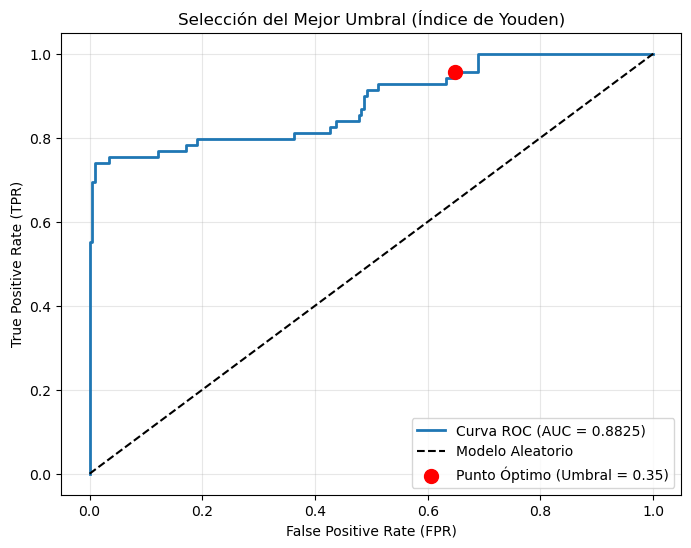

In [92]:
# PASO 6: Generar predicciones de probabilidad y calcular el AUC
y_pred_proba = pipeline_insurance.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC del modelo: {auc_score:.4f}")

# PASO 7: Graficar la Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Curva ROC (AUC = {auc_score:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Modelo Aleatorio')

# Resaltamos el punto óptimo
plt.scatter(fpr[best_index], tpr[best_index], color='red', marker='o', s=100, 
            label=f'Punto Óptimo (Umbral = {best_threshold:.2f})', zorder=5)

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Selección del Mejor Umbral (Índice de Youden)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


In [93]:
# PASO 8 y 9: Umbral óptimo (Youden) vs umbral por defecto (0.5)

# Reusar y_pred_proba ya calculado en la celda anterior
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
youden_j = tpr - fpr
best_index = np.argmax(youden_j)
best_threshold = thresholds[best_index]

print(f"\nUmbral por defecto: 0.5000")
print(f"Umbral óptimo (Youden): {best_threshold:.4f}")

# Predicciones con ambos umbrales
y_pred_05 = (y_pred_proba >= 0.5).astype(int)
y_pred_optimal = (y_pred_proba >= best_threshold).astype(int)

print("\n--- Evaluación con Umbral 0.5 ---")
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_05))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_05))

print(f"\n--- Evaluación con Umbral Óptimo ({best_threshold:.4f}) ---")
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_optimal))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_optimal))


Umbral por defecto: 0.5000
Umbral óptimo (Youden): 0.8092

--- Evaluación con Umbral 0.5 ---
Matriz de Confusión:
[[197   2]
 [ 18  51]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       199
           1       0.96      0.74      0.84        69

    accuracy                           0.93       268
   macro avg       0.94      0.86      0.89       268
weighted avg       0.93      0.93      0.92       268


--- Evaluación con Umbral Óptimo (0.8092) ---
Matriz de Confusión:
[[197   2]
 [ 18  51]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       199
           1       0.96      0.74      0.84        69

    accuracy                           0.93       268
   macro avg       0.94      0.86      0.89       268
weighted avg       0.93      0.93      0.92       268



# Cierre 

## Resumen:

Para cerrar nuestra sesión, recapitularemos la formulación matemática y metodológica que hemos construido hoy para resolver problemas de clasificación binaria:

* ***Inviabilidad de OLS en clasificación***: Demostramos analíticamente que la Regresión Lineal Múltiple y la minimización del Error Cuadrático Medio (MSE) producen proyecciones fuera del rango $[0, 1]$, haciéndolas incompatibles con un marco probabilístico.

* ***Proyección probabilística (Función Sigmoide)***: Introdujimos la transformación sigmoide para mapear la combinación lineal $z = X\beta$ a un espacio de probabilidades válidas.

* ***Asimetría en la función de costo (Log-Loss)***: Sustituimos el MSE por la Entropía Cruzada Binaria (Log-Loss). Analizamos cómo el comportamiento asintótico del logaritmo penaliza de forma no lineal las predicciones incorrectas emitidas con alta confianza estadística.

* ***Optimización de parámetros***: Comprobamos que el gradiente de la función Log-Loss mantiene una estructura algebraica equivalente a la de OLS. Esto permite utilizar el Gradiente Descendente y solvers avanzados iterativos (algoritmo L-BFGS) para la actualización de los pesos $\beta$.

* ***Evaluación en clases desbalanceadas***: Descartamos el Accuracy como métrica principal ante distribuciones asimétricas. Implementamos la Matriz de Confusión para extraer Precision y Recall, métricas que cuantifican con exactitud el costo de los Errores Tipo I y Tipo II.

* ***Capacidad de discriminación global (ROC-AUC)***: Utilizamos la Curva ROC y el estadístico AUC para evaluar la capacidad intrínseca del modelo para separar clases independientemente del punto de corte, calculando el umbral óptimo de operación matemática mediante el Índice de Youden.

## La decisión operativa del modelo

El modelo logístico no emite clasificaciones discretas absolutas; calcula una distribución de probabilidades condicionada a las características de entrada. La asignación final a la Clase 0 o a la Clase 1 depende de un umbral de decisión. Desplazar este umbral desde el valor estándar de 0.5 hacia el óptimo calculado (Youden) o ajustarlo a requerimientos de negocio representa la transición entre la optimización matemática del algoritmo y su despliegue funcional en un entorno real.

## Limitación geométrica y transición 

El modelo que desarrollamos hoy es robusto, pero está restringido por una limitación topológica fundamental. La frontera de decisión generada por la ecuación $X\beta = 0$ es estrictamente un hiperplano lineal. Si la distribución espacial de las clases requiere una separación no lineal (por ejemplo, topologías concéntricas), este algoritmo presentará un alto sesgo (underfitting). En la próxima sesión abordaremos esta limitación mediante algoritmos de partición espacial y proyección a dimensiones superiores, introduciendo los Árboles de Decisión y las Máquinas de Vectores de Soporte (SVM).